## Práctica 8: Reconocimiento con redes neuronales.
### Autor: Juan Manuel Mena Hernandez
### Fecha: 05-05-2026


### EJERCICIO 1. CREACION DE UN PERCEPTRÓN SIMPLE PARA TRABAJAR CON PUERTAS LÓGICAS

En este ejercicio, vamos a realizar un perceptron capaz de resolver funciones lógicas. Iniciaremos con la unidad básica de aprendizaje: la neurona. En este ejercicio entrenaremos un perceptrón para resolver funciones l´ogicas, entendiendo el papel de los pesos y el sesgo (bias).


In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Silenciar logs innecesarios de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Datos de entrenamiento: Puerta lógica AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

# Configuración del modelo
model = Sequential([
    Input(shape=(2,)),
    Dense(1, activation='sigmoid')
])

# Compilación
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.1),
    metrics=['accuracy']
)

# Entrenamiento
print("Entrenando el modelo...")
model.fit(X, y, epochs=500, verbose=0)

# Predicción
test_data = np.array([[1, 1]])
prediccion = model.predict(test_data, verbose=0)

print(f"\nPredicción para [1,1]: {prediccion[0][0]:.4f}")
print(f"¿Es True?: {prediccion[0][0] > 0.5}")

Entrenando el modelo...

Predicción para [1,1]: 0.9852
¿Es True?: True


El script implementa una red neuronal básica utilizando la librería TensorFlow para resolver el comportamiento lógico de una puerta AND. 

El proceso comienza definiendo un conjunto de datos de entrenamiento donde la salida solo es verdadera si ambas entradas son uno. El modelo se estructura como una red secuencial con una única neurona y un optimizador Adam, ideal para problemas de clasificación. 

Tras entrenar durante quinientas iteraciones, el código realiza una inferencia sobre el caso de prueba uno-uno y evalúa el resultado numérico mediante un umbral de decisión para confirmar si el sistema ha aprendido correctamente que dicha combinación representa un valor verdadero.

## EJERCICIO 2. CLASIFICACIÓN DE DÍGITOS MANUSCRITOS (MNIST) CON MLP

En este ejercicio, se propone realizar clasificación de dígitos escritos a mano. El conjunto MNIST es el “Hello World” de las redes neuronales. Para ello, implementaremos una red densa (Multi-Layer Perceptron) para reconocer números del 0 al 9 escritos a mano.


In [12]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

# Limpiar logs de TensorFlow (evita mensajes de advertencia innecesarios)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 1. Carga de datos (MNIST)
print("Cargando el dataset MNIST...")
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalización (Escalar valores de píxeles de 0-255 a 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. Definición del Modelo
model = Sequential([
    Input(shape=(28, 28)),          # Capa de entrada: Imágenes de 28x28 píxeles
    Flatten(),                      # Convierte la matriz 28x28 en un vector de 784
    Dense(128, activation='relu'),  # Capa oculta con 128 neuronas
    Dense(10, activation='softmax') # Capa de salida: 10 neuronas (una por número)
])

# 4. Compilación
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Entrenamiento
print("\nIniciando entrenamiento...")
model.fit(x_train, y_train, epochs=5)

# Guardar el modelo entrenado
model.save("mi_red_mnist.keras")

# 6. Evaluación
print("\nEvaluando en datos de test...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\nPrecisión final en test: {test_acc:.4f}")

Cargando el dataset MNIST...

Iniciando entrenamiento...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9265 - loss: 0.2549
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9657 - loss: 0.1140
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9756 - loss: 0.0781
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9819 - loss: 0.0581
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9862 - loss: 0.0456

Evaluando en datos de test...
313/313 - 0s - 1ms/step - accuracy: 0.9786 - loss: 0.0719

Precisión final en test: 0.9786


El script implementa una red neuronal profunda utilizando TensorFlow para clasificar imágenes de dígitos escritos a mano del conjunto de datos MNIST. 

El proceso comienza cargando y normalizando las imágenes, lo que facilita el aprendizaje del modelo. 

La arquitectura de la red se define de forma secuencial, iniciando con una capa que aplana la matriz bidimensional de los dibujos en un vector unidimensional, seguida de una capa oculta densa de ciento veintiocho neuronas con activación ReLU y una capa de salida con diez neuronas y activación Softmax para asignar probabilidades a cada posible dígito. Tras compilar el modelo con el optimizador Adam y la función de pérdida de entropía cruzada, el código entrena la red durante cinco iteraciones y guarda el cerebro resultante en un archivo local. 

Finalmente, el programa evalúa el rendimiento del sistema con datos que nunca ha visto, imprimiendo el porcentaje de precisión alcanzado en la identificación de los números.

## EJERCICIO 3. CLASIFICACIÓN DE ROPA (FASHION-MNIST) CON CNN

En este ejercicio aplicaremos una CNN para clasificar imágenes de prendas de vestir. Este
ejercicio demuestra cómo las redes convolucionales capturan texturas y formas de manera más eficiente que las redes densas.


Cargando Fashion MNIST... -
Entrenando...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8120 - loss: 0.5279 - val_accuracy: 0.8642 - val_loss: 0.3865
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8758 - loss: 0.3454 - val_accuracy: 0.8817 - val_loss: 0.3217
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8906 - loss: 0.3018 - val_accuracy: 0.8895 - val_loss: 0.3064
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9007 - loss: 0.2723 - val_accuracy: 0.9005 - val_loss: 0.2744
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9094 - loss: 0.2498 - val_accuracy: 0.9007 - val_loss: 0.2698

Resultado de la prueba...
Realidad: Zapatilla
Predicción: Zapatilla


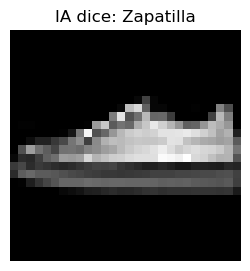

In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Limpieza de logs

import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np
import matplotlib.pyplot as plt

# Nombres de las clases (Para que sea legible)
class_names = [
    'Camiseta/Top', 'Pantalón', 'Jersey', 'Vestido',
    'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla',
    'Bolso', 'Botín'
]

# Carga y Preprocesamiento
print("Cargando Fashion MNIST... -")
fashion = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion.load_data()

# Normalizar (0-1) y Reshape (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Definición del Modelo (CNN de dos niveles)
model = models.Sequential([
    Input(shape=(28, 28, 1)),

    # Bloque 1: Detecta bordes y formas básicas
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloque 2: Detecta patrones más complejos (texturas, formas de ropa)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Clasificación
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando...")
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# Elegimos una imagen aleatoria del test
idx = np.random.randint(0, len(x_test))
imagen = x_test[idx]
etiqueta_real = y_test[idx]

# Predicción
prediccion_raw = model.predict(np.expand_dims(imagen, axis=0), verbose=0)
clase_predicha = np.argmax(prediccion_raw)

print(f"\nResultado de la prueba...")
print(f"Realidad: {class_names[etiqueta_real]}")
print(f"Predicción: {class_names[clase_predicha]}")

plt.figure(figsize=(3, 3))
plt.imshow(imagen.reshape(28, 28), cmap='gray')
plt.title(f"IA dice: {class_names[clase_predicha]}")
plt.axis('off')
plt.show()

El script implementa una red neuronal convolucional (CNN) utilizando TensorFlow para clasificar prendas de vestir del conjunto de datos Fashion MNIST. 

El proceso comienza cargando las imágenes y ajustando sus dimensiones para incluir un canal de profundidad, normalizando además los valores de los píxeles al rango entre cero y uno. 

La arquitectura del modelo se organiza en dos bloques de capas convolucionales y de agrupación (MaxPooling), diseñados específicamente para extraer características espaciales como bordes, texturas y formas complejas de la ropa de manera jerárquica. 

Tras estas capas, la información se aplana en un vector para pasar por una capa densa de clasificación que utiliza la función Softmax para determinar la probabilidad de pertenencia a una de las diez categorías de prendas. 

El código entrena el modelo durante cinco iteraciones, seleccionando después una imagen al azar del conjunto de pruebas para realizar una inferencia y mostrar visualmente mediante Matplotlib si la predicción de la inteligencia artificial coincide con la etiqueta real de la prenda.

## EJERCICIO 4. AJUSTE FINO (FINE-TUNING) PARA CLASIFICACIÓN PERSONALIZADA

En este ejercicio se pretende entrenar nuestra propia red partiendo de una ya existente.
Tomaremos una red experta y la re-entrenaremos para una tarea específica (ej: distinguir entretipos de frutas). Solo ajustaremos las ´ultimas capas para adaptar el conocimiento previo a nuestro dataset. Deber´eis de presentar ejemplo de c´omo funciona tras el re-entrenamiento con vuestras propias fotos de frutas.

In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silenciar logs de TensorFlow

import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np

# Preparar datos (MNIST)
# Las CNN necesitan 3 dimensiones: (Alto, Ancho, Canales).
# MNIST viene como (28, 28), así que añadimos el "1" del canal (escala de grises).
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Definición del Modelo
model = models.Sequential([
    # Capa de Entrada Explícita: (Alto, Ancho, Canales de color)
    Input(shape=(28, 28, 1)),

    # Bloque de Convolución
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Aplanado y Clasificación
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Resumen y Compilación
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar
print("\n- Entrenando CNN.... ")
model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)


- Entrenando CNN.... 
Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9357 - loss: 0.2201 - val_accuracy: 0.9748 - val_loss: 0.0910
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9794 - loss: 0.0700 - val_accuracy: 0.9843 - val_loss: 0.0580
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9861 - loss: 0.0474 - val_accuracy: 0.9863 - val_loss: 0.0515


El script implementa una red neuronal convolucional simplificada para el reconocimiento de dígitos escritos a mano utilizando el conjunto de datos MNIST. 

El proceso inicia con la reestructuración de las imágenes para añadir un canal de profundidad obligatorio para este tipo de arquitecturas y la normalización de los valores de intensidad lumínica. 

El modelo se define mediante una capa de entrada explícita seguida de un bloque de procesamiento espacial que combina una capa convolucional para la extracción de características visuales básicas y una capa de agrupación para reducir la dimensionalidad. 

Posteriormente, la información se transforma en un vector unidimensional mediante la función de aplanado para alimentar una red densa que clasifica los patrones en diez categorías posibles. 

Finalmente, el código compila la red con el optimizador Adam y ejecuta un entrenamiento de tres iteraciones, empleando una fracción de los datos para validar la precisión del aprendizaje en cada etapa.

## EJERCICIO 5. RECONOCIMIENTO DE DÍGITOS EN TIEMPO REAL POR WEBCAM

En este ejercicio integraremos nuestra red entrenada con el flujo de vídeo. El sistema capturará el área de la cámara, la pre-procesará y mostrará la predicción del número detectado en tiempo real. Previamente hemos creado y entrenado el modelo utilizando el procesamiento del conjunto de números de mnist. Una vez guardado el modelo es utilizado para nuestro ejercicio de reconocimiento en tiempo real.
Nota: Para este ejercicio, se precisa que se envíen las capturas de pantalla de los números detectados por el sistema para comprobar que funciona.

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import sys

# Silenciar logs de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("Cargando modelo ...")
try:
    model = tf.keras.models.load_model('mi_red_mnist.keras')
    print("Modelo cargado correctamente.")
except Exception as e:
    print(f"Error cargando el modelo: {e}")
    sys.exit(1)

# Iniciar Webcam con gestión de errores
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)  # <-- cambio aquí

# Si falla, probar otras cámaras / backends
if not cap.isOpened():
    print("Intentando con otra cámara/backend...")
    cap = cv2.VideoCapture(1)
if not cap.isOpened():
    print("Error: No se puede acceder a la webcam.")
    sys.exit(1)

cv2.namedWindow("Webcam en tiempo real", cv2.WINDOW_NORMAL)
cv2.namedWindow("Ojo de la IA", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Ojo de la IA", 200, 200)

print("Cámara iniciada. Pulsa 'q' en la ventana para salir.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error leyendo frame (¿cámara desconectada?) ")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Definir ROI (Región de Interés)
        height, width = gray.shape
        tamano_caja = 200
        x1 = int(width / 2 - tamano_caja / 2)
        y1 = int(height / 2 - tamano_caja / 2)
        x2 = int(width / 2 + tamano_caja / 2)
        y2 = int(height / 2 + tamano_caja / 2)

        roi = gray[max(0, y1):min(height, y2), max(0, x1):min(width, x2)]

        if roi.size > 0:
            roi_resized = cv2.resize(roi, (28, 28))
            roi_resized = cv2.bitwise_not(roi_resized)
            roi_norm = roi_resized.reshape(1, 28, 28, 1).astype('float32') / 255.0

            prediccion = model.predict(roi_norm, verbose=0)
            clase = np.argmax(prediccion)
            confianza = np.max(prediccion)

            color = (0, 255, 0) if confianza > 0.7 else (0, 0, 255)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            texto = f"Num: {clase} ({confianza * 100:.0f}%)"
            cv2.putText(frame, texto, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            cv2.imshow("Ojo de la IA", roi_resized)

        cv2.imshow("Webcam en tiempo real", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Salir.")
            break

except KeyboardInterrupt:
    print("Interrupción de teclado detectada.")

finally:
    print("Liberando recursos")
    cap.release()
    cv2.destroyAllWindows()

Cargando modelo ...
Modelo cargado correctamente.
Cámara iniciada. Pulsa 'q' en la ventana para salir.


![Ejemplo EJ 5](imagen_ej5.png)

El script implementa un sistema de reconocimiento de dígitos en tiempo real que utiliza una red neuronal previamente entrenada y la cámara web del equipo. 


El proceso comienza cargando un modelo de inteligencia artificial en formato Keras y configurando la captura de video. Dentro de un bucle continuo, el código define un área cuadrada central en la imagen de video denominada región de interés, la cual se extrae, se convierte a escala de grises y se redimensiona a veintiocho por veintiocho píxeles para igualar el formato de entrenamiento del modelo. 

Luego se invierten los colores mediante bitwise_not para asegurar que el dígito aparezca blanco sobre fondo negro, permitiendo que la red realice una inferencia probabilística sobre el número detectado. 

Finalmente, el programa dibuja un cuadro de color verde o rojo en función del nivel de confianza, proyecta el número predicho sobre el flujo de video en vivo y muestra una ventana secundaria con la visión procesada que la inteligencia artificial está analizando.

## EJERCICIO 6. TRANSFER LEARNING CON MOBILENETV2

En este ejercicio pretendemos reconocer objetos a visualizados a través de la webcam. No
siempre es necesario entrenar una red desde cero. Utilizaremos una red pre-entrenada por Google (MobileNetV2) para reconocer más de 1.000 categorías de objetos comunes con una precisión profesional.
Nota: Para este ejercicio, se precisa que se envíen las capturas de pantalla de los objetos detectados por el sistema para comprobar que funciona.


In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions

# Silenciar logs de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("Cargando MobileNetV2...")
try:
    model = MobileNetV2(weights='imagenet')
    print("Modelo cargado.")
except Exception as e:
    print(f"Error cargando modelo")
    exit()

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("No se detecta la cámara.")
    exit()

print("Iniciando. Pulsa 'q' o cierra la ventana para salir")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error de lectura de cámara.")
            break

        # MobileNet espera imágenes de 224x224
        img_resized = cv2.resize(frame, (224, 224))
        
        # Preprocesamiento
        img_array = np.expand_dims(img_resized, axis=0)
        img_preprocessed = preprocess_input(img_array)

        # Predicción
        preds = model.predict(img_preprocessed, verbose=0)
        resultados = decode_predictions(preds, top=3)[0]

        # Formateo de etiquetas
        texto_top = f"{resultados[0][1]}: {resultados[0][2]*100:.1f}%"
        cv2.putText(frame, texto_top, (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        texto_segundo = f"o {resultados[1][1]}: {resultados[1][2]*100:.1f}%"
        cv2.putText(frame, texto_segundo, (10, 70), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        cv2.imshow('Detector de Objetos', frame)

        tecla = cv2.waitKey(1) & 0xFF
        if tecla == ord('q'):
            break

        if cv2.getWindowProperty('Detector de Objetos', cv2.WND_PROP_VISIBLE) < 1:
            break

except KeyboardInterrupt:
    print("\nInterrumpido por el usuario (Ctrl+C).")

finally:
    cap.release()
    cv2.destroyAllWindows()

Cargando MobileNetV2...
Modelo cargado.
Iniciando. Pulsa 'q' o cierra la ventana para salir


error: OpenCV(4.13.0) C:\Users\task_177678477250286\croot\opencv-suite_1776784890358\work\modules\highgui\src\window_QT.cpp:179: error: (-27:Null pointer) NULL guiReceiver (please create a window) in function 'cvGetPropVisible_QT'


![Ejemplo EJ6](imagen_ej6.png)

El script implementa un sistema de reconocimiento de objetos en tiempo real utilizando la cámara web y el modelo preentrenado MobileNetV2, el cual está diseñado para ser eficiente en dispositivos móviles. 

El proceso comienza cargando los pesos de ImageNet y configurando la captura de video; en cada iteración del bucle, el código redimensiona el fotograma actual a 224 por 224 píxeles para cumplir con los requisitos de entrada del modelo. 

Tras expandir las dimensiones de la matriz y aplicar un preprocesamiento específico para ajustar los valores de color, la red neuronal realiza una inferencia que devuelve las probabilidades para mil categorías diferentes. 

Mediante la función decode_predictions, el programa extrae los tres resultados con mayor probabilidad y los imprime directamente sobre el flujo de video en vivo, mostrando el nombre del objeto y el porcentaje de confianza en una interfaz gráfica que se mantiene activa hasta que el usuario decide cerrarla o presionar la tecla de salida.